# Per-patient contrastive separability of `cloned`

Assumes **`reps`** (SCEPTR embeddings, shape `(27159, 64)`) and **`mdata`** (MuData with `obs['patient']` and `obs['cloned']`) are already in the namespace from your existing notebook cells.

In [24]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device : {device}')

device : cpu


## SCEPTR

In [25]:
from pandas import DataFrame
import sceptr
import pandas as pd
import muon as mu

In [26]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "T_DE_per_sample_TCRembvdjdb_singlets.h5mu"
DATA_PATH = path + filename

mdata_ori = mu.read(DATA_PATH)

In [27]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 27159 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'vdjdb_match', 'vdjdb_label'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	27159 × 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	27159 × 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [28]:
clone_df = mdata.obs[["unique_clone_id", "vdjdb_match",
                      "VJ_1_cdr3_aa","VJ_1_v_call","VJ_1_j_call",
            "VDJ_1_cdr3_aa","VDJ_1_v_call","VDJ_1_j_call"]]

# Create a dictionary mapping the old names to the new names
rename_mapping = {
    "VJ_1_cdr3_aa": "cdr3_a_aa",
    "VJ_1_v_call": "v_a_gene",
    "VJ_1_j_call": "j_a_gene",
    "VDJ_1_cdr3_aa": "cdr3_b_aa",
    "VDJ_1_v_call": "v_b_gene",
    "VDJ_1_j_call": "j_b_gene"
}

# Rename the columns
clone_df = clone_df.rename(columns=rename_mapping)
print(clone_df.head())               

                       unique_clone_id  vdjdb_match     cdr3_a_aa  v_a_gene  \
LT1_CACATAGAGTGTACCT-1         Lung1_0        False  ALGSQGGSEKLV   TRAV9-2   
LN3_CTTAGGATCGCGCCAA-2     Lung3_10014        False    ALWLYGNKLV    TRAV16   
LN1_CCTATTAAGTCTCAAC-1      Lung1_1003         True    AMRYTGNQFY  TRAV12-3   
LN3_GTAACTGAGTTAGGTA-2     Lung3_10035         True   AVNNNAGNMLT   TRAV8-1   
LN3_GACGCGTTCAGTGTTG-2     Lung3_10046        False  AVCSGGSNYKLT    TRAV21   

                       j_a_gene       cdr3_b_aa  v_b_gene j_b_gene  
LT1_CACATAGAGTGTACCT-1   TRAJ57  ASSQDQTARSYGYT   TRBV4-1  TRBJ1-2  
LN3_CTTAGGATCGCGCCAA-2   TRAJ47  ASRWGKGARTGELF    TRBV19  TRBJ2-2  
LN1_CCTATTAAGTCTCAAC-1   TRAJ49  ASSSRLAGFTGELF   TRBV5-4  TRBJ2-2  
LN3_GTAACTGAGTTAGGTA-2   TRAJ39   ASSLGGYSNQPQH   TRBV7-9  TRBJ1-5  
LN3_GACGCGTTCAGTGTTG-2   TRAJ53  SAPDRGVPSNYGYT  TRBV20-1  TRBJ1-2  


In [29]:
match_df = clone_df[clone_df["vdjdb_match"] == True]
unmatch_df = clone_df[clone_df["vdjdb_match"] == False]

In [30]:
import logging
import pandas as pd
import tidytcells as tt

logging.basicConfig(level=logging.WARNING)

# ---- 2. Map AIRR/scirpy columns -> TRAV/CDR3A/TRBV/CDR3B (+ J genes) ------
def prefix_c(s):
    """Prepend 'C' to CDR3 aa seqs; leave empty/NaN as ''."""
    s = s.astype(str)
    return ("C" + s + "F").where(s.notna() & (s != "") & (s != "nan"), "")

In [31]:
tcr_all = pd.DataFrame({
    "TRAV":  clone_df["v_a_gene"].values,   # keep raw IMGT symbol (e.g. TRAV1-2*01)
    "TRAJ":  clone_df["j_a_gene"].values,
    "CDR3A": prefix_c(clone_df["cdr3_a_aa"]).values,
    "TRBV":  clone_df["v_b_gene"].values,
    "TRBJ":  clone_df["j_b_gene"].values,
    "CDR3B": prefix_c(clone_df["cdr3_b_aa"]).values,
},  index=clone_df.index)

# ---- 3. Standardize V/J genes to IMGT gene-level -------------------------
# NOTE 1: set species correctly. "homosapiens" / "musmusculus" / "any".
SPECIES = "homosapiens"
cols = ["TRAV", "TRAJ", "TRBV", "TRBJ"]
tcr_all[cols] = tcr_all[cols].map(
    lambda x: tt.tr.standardize(
        symbol=x,
        species=SPECIES,
        precision="gene",
        enforce_functional=True,   # drop ORF/pseudogenes like TRBV21-1
        on_fail="reject",          # return None on failure
        log_failures=True,
    ),
    na_action="ignore",
)

print(tcr_all.head())

                            TRAV    TRAJ           CDR3A      TRBV     TRBJ  \
LT1_CACATAGAGTGTACCT-1   TRAV9-2  TRAJ57  CALGSQGGSEKLVF   TRBV4-1  TRBJ1-2   
LN3_CTTAGGATCGCGCCAA-2    TRAV16  TRAJ47    CALWLYGNKLVF    TRBV19  TRBJ2-2   
LN1_CCTATTAAGTCTCAAC-1  TRAV12-3  TRAJ49    CAMRYTGNQFYF   TRBV5-4  TRBJ2-2   
LN3_GTAACTGAGTTAGGTA-2   TRAV8-1  TRAJ39   CAVNNNAGNMLTF   TRBV7-9  TRBJ1-5   
LN3_GACGCGTTCAGTGTTG-2    TRAV21  TRAJ53  CAVCSGGSNYKLTF  TRBV20-1  TRBJ1-2   

                                   CDR3B  
LT1_CACATAGAGTGTACCT-1  CASSQDQTARSYGYTF  
LN3_CTTAGGATCGCGCCAA-2  CASRWGKGARTGELFF  
LN1_CCTATTAAGTCTCAAC-1  CASSSRLAGFTGELFF  
LN3_GTAACTGAGTTAGGTA-2   CASSLGGYSNQPQHF  
LN3_GACGCGTTCAGTGTTG-2  CSAPDRGVPSNYGYTF  


In [32]:
tcr_matched = pd.DataFrame({
    "TRAV":  match_df["v_a_gene"].values,   # keep raw IMGT symbol (e.g. TRAV1-2*01)
    "TRAJ":  match_df["j_a_gene"].values,
    "CDR3A": prefix_c(match_df["cdr3_a_aa"]).values,
    "TRBV":  match_df["v_b_gene"].values,
    "TRBJ":  match_df["j_b_gene"].values,
    "CDR3B": prefix_c(match_df["cdr3_b_aa"]).values,
}, index=match_df.index)

# ---- 3. Standardize V/J genes to IMGT gene-level -------------------------
# NOTE 1: set species correctly. "homosapiens" / "musmusculus" / "any".
SPECIES = "homosapiens"
cols = ["TRAV", "TRAJ", "TRBV", "TRBJ"]
tcr_matched[cols] = tcr_matched[cols].map(
    lambda x: tt.tr.standardize(
        symbol=x,
        species=SPECIES,
        precision="gene",
        enforce_functional=True,   # drop ORF/pseudogenes like TRBV21-1
        on_fail="reject",          # return None on failure
        log_failures=True,
    ),
    na_action="ignore",
)

print(tcr_matched.head())

                                TRAV    TRAJ           CDR3A      TRBV  \
LN1_CCTATTAAGTCTCAAC-1      TRAV12-3  TRAJ49    CAMRYTGNQFYF   TRBV5-4   
LN3_GTAACTGAGTTAGGTA-2       TRAV8-1  TRAJ39   CAVNNNAGNMLTF   TRBV7-9   
LN3_GACTACAGTCTAAACC-2         TRAV2  TRAJ43     CAAYNNNDMRF   TRBV5-1   
LT1_TCAGATGAGGGATCTG-1  TRAV38-2/DV8  TRAJ44  CAYSLTGTASKLTF  TRBV29-1   
LN3_TGTTCCGGTTGCTCCT-2      TRAV12-2  TRAJ20      CAVSDYKLSF   TRBV5-6   

                           TRBJ              CDR3B  
LN1_CCTATTAAGTCTCAAC-1  TRBJ2-2   CASSSRLAGFTGELFF  
LN3_GTAACTGAGTTAGGTA-2  TRBJ1-5    CASSLGGYSNQPQHF  
LN3_GACTACAGTCTAAACC-2  TRBJ2-1    CASSLAGQVTDEQFF  
LT1_TCAGATGAGGGATCTG-1  TRBJ1-1     CSVTTGYMNTEAFF  
LN3_TGTTCCGGTTGCTCCT-2  TRBJ1-1  CASSLGGGPPLNTEAFF  


In [33]:
tcr_unmatched = pd.DataFrame({
    "TRAV":  unmatch_df["v_a_gene"].values,   # keep raw IMGT symbol (e.g. TRAV1-2*01)
    "TRAJ":  unmatch_df["j_a_gene"].values,
    "CDR3A": prefix_c(unmatch_df["cdr3_a_aa"]).values,
    "TRBV":  unmatch_df["v_b_gene"].values,
    "TRBJ":  unmatch_df["j_b_gene"].values,
    "CDR3B": prefix_c(unmatch_df["cdr3_b_aa"]).values,
},index=unmatch_df.index)

# ---- 3. Standardize V/J genes to IMGT gene-level -------------------------
# NOTE 1: set species correctly. "homosapiens" / "musmusculus" / "any".
SPECIES = "homosapiens"

cols = ["TRAV", "TRAJ", "TRBV", "TRBJ"]
tcr_unmatched[cols] = tcr_unmatched[cols].map(
    lambda x: tt.tr.standardize(
        symbol=x,
        species=SPECIES,
        precision="gene",
        enforce_functional=True,   # drop ORF/pseudogenes like TRBV21-1
        on_fail="reject",          # return None on failure
        log_failures=True,
    ),
    na_action="ignore",
)

print(tcr_unmatched.head())

                                TRAV    TRAJ              CDR3A      TRBV  \
LT1_CACATAGAGTGTACCT-1       TRAV9-2  TRAJ57     CALGSQGGSEKLVF   TRBV4-1   
LN3_CTTAGGATCGCGCCAA-2        TRAV16  TRAJ47       CALWLYGNKLVF    TRBV19   
LN3_GACGCGTTCAGTGTTG-2        TRAV21  TRAJ53     CAVCSGGSNYKLTF  TRBV20-1   
LT1_TCAGGTACATCACAAC-1  TRAV38-2/DV8  TRAJ45     CAYATGGGADGLTF  TRBV12-4   
LN3_TACTCATGTACTCGCG-2      TRAV26-1  TRAJ45  CIVRVRRAGGGADGLTF   TRBV5-1   

                           TRBJ             CDR3B  
LT1_CACATAGAGTGTACCT-1  TRBJ1-2  CASSQDQTARSYGYTF  
LN3_CTTAGGATCGCGCCAA-2  TRBJ2-2  CASRWGKGARTGELFF  
LN3_GACGCGTTCAGTGTTG-2  TRBJ1-2  CSAPDRGVPSNYGYTF  
LT1_TCAGGTACATCACAAC-1  TRBJ2-7  CASSSSGGRFLYEQYF  
LN3_TACTCATGTACTCGCG-2  TRBJ2-3   CASSPGHRDLDTQYF  


In [34]:
reps = sceptr.calc_vector_representations(tcr_matched)
reps.shape

(4429, 64)

In [40]:
mdata = mdata[mdata.obs['vdjdb_match']==True]

## Architecture

In [41]:
class ProjectionHead(nn.Module):
    """
    Lightweight MLP on top of frozen SCEPTR embeddings.
    Maps (n, 64) -> L2-normalised (n, 64) on the unit hypersphere.
    """
    def __init__(self, input_dim=64, hidden_dim=128, output_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class SupervisedContrastiveLoss(nn.Module):
    """
    Khosla et al. (2020). Positive pairs = same 'cloned' label.
    Temperature=0.07 matches SCEPTR paper convention.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        N = features.shape[0]
        sim = torch.matmul(features, features.T) / self.temperature

        labels_col = labels.unsqueeze(1)
        pos_mask = (labels_col == labels_col.T).float()
        pos_mask.fill_diagonal_(0.0)

        denom_mask = torch.ones(N, N, device=features.device)
        denom_mask.fill_diagonal_(0.0)

        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim = sim - sim_max.detach()

        exp_sim  = torch.exp(sim) * denom_mask
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-9)

        n_pos = pos_mask.sum(dim=1)
        loss  = -(pos_mask * log_prob).sum(dim=1) / (n_pos + 1e-9)

        valid = n_pos > 0
        return loss[valid].mean() if valid.any() else torch.tensor(0.0, requires_grad=True)

## Training and evaluation helpers

In [42]:
def train_projection_head(X_train, y_train,
                           n_epochs=60, batch_size=64,
                           lr=1e-3, temperature=0.07):
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_train, dtype=torch.long).to(device)

    model     = ProjectionHead().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = SupervisedContrastiveLoss(temperature)

    effective_bs = min(batch_size, len(X_train))
    loader = DataLoader(
        TensorDataset(X_t, y_t),
        batch_size=effective_bs,
        shuffle=True,
        drop_last=(len(X_train) > effective_bs),
    )

    model.train()
    for _ in range(n_epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

    return model


@torch.no_grad()
def project(model, X):
    model.eval()
    return model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy()


def separability_metrics(X, y, min_class_size=1):
    """Logistic-regression AUROC + silhouette on the given split."""
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2 or counts.min() < min_class_size:
        return None
    try:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42)
    except ValueError:
        return None

    clf = LogisticRegression(max_iter=1000, random_state=42,
                              class_weight='balanced')
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)

    auroc = (roc_auc_score(y_te, proba[:, 1])
             if proba.shape[1] == 2
             else roc_auc_score(y_te, proba, multi_class='ovr', average='macro'))

    sil = silhouette_score(X, y) if len(X) > 2 else float('nan')
    return {'auroc': auroc, 'silhouette': sil}

## Per-patient loop

In [43]:
def run_per_patient(embeddings, obs,
                    patient_col='patient', cloned_col='cloned',
                    min_class_size=5, train_frac=0.8,
                    n_epochs=60, batch_size=64, temperature=0.07):
    """
    For each patient:
      - 80/20 stratified split (train projection head on 80%, evaluate on 20%)
      - AUROC + silhouette before and after contrastive projection
    """
    le    = LabelEncoder()
    y_all = le.fit_transform(obs[cloned_col].values.astype(str))

    records  = []
    patients = obs[patient_col].unique()

    for i, patient in enumerate(patients):
        print(f'[{i+1}/{len(patients)}] {patient}', end=' ')

        mask = obs[patient_col].values == patient
        X, y = embeddings[mask], y_all[mask]

        classes, counts = np.unique(y, return_counts=True)
        if len(classes) < 2 or counts.min() < min_class_size:
            print(f'— skipped (counts: {dict(zip(le.inverse_transform(classes), counts))})')
            continue

        try:
            idx = np.arange(len(y))
            idx_tr, idx_te = train_test_split(
                idx, test_size=1 - train_frac, stratify=y, random_state=42)
        except ValueError:
            print('— skipped (split failed)')
            continue

        X_tr, y_tr = X[idx_tr], y[idx_tr]
        X_te, y_te = X[idx_te], y[idx_te]

        before = separability_metrics(X_te, y_te)
        if before is None:
            print('— skipped (metrics failed)')
            continue

        model  = train_projection_head(X_tr, y_tr,
                                        n_epochs=n_epochs,
                                        batch_size=batch_size,
                                        temperature=temperature)
        X_proj = project(model, X_te)
        after  = separability_metrics(X_proj, y_te)
        if after is None:
            print('— skipped (post-metrics failed)')
            continue

        print(f'AUROC {before["auroc"]:.3f} -> {after["auroc"]:.3f}')

        records.append({
            'patient':      patient,
            'n_cells':      mask.sum(),
            'cloned_frac':  round(counts[1] / len(y), 3),
            'auroc_before': round(before['auroc'], 4),
            'auroc_after':  round(after['auroc'],  4),
            'auroc_delta':  round(after['auroc']  - before['auroc'],  4),
            'sil_before':   round(before['silhouette'], 4),
            'sil_after':    round(after['silhouette'],  4),
            'sil_delta':    round(after['silhouette']  - before['silhouette'], 4),
        })

    return pd.DataFrame(records).sort_values('auroc_after', ascending=False)

## Run  —  plug in `reps` and `mdata`

In [44]:
results = run_per_patient(
    embeddings    = reps,          # (27159, 64) from your notebook
    obs           = mdata.obs,     # DataFrame with 'patient' and 'cloned'
    patient_col   = 'patient',
    cloned_col    = 'cloned',
    min_class_size= 5,             # skip patients with < 5 cells per class
    train_frac    = 0.8,
    n_epochs      = 60,
    batch_size    = 64,
    temperature   = 0.07,
)

results

[1/14] Lung1 AUROC 0.385 -> 0.282
[2/14] Lung3 AUROC 0.691 -> 0.382
[3/14] Lung4 AUROC 0.625 -> 0.625
[4/14] Lung5 AUROC 0.533 -> 0.567
[5/14] Lung6 AUROC 0.321 -> 0.185
[6/14] Endo1 AUROC 0.833 -> 0.833
[7/14] Endo2 AUROC 1.000 -> 0.800
[8/14] Endo3 AUROC 0.250 -> 0.000
[9/14] Colon1 AUROC 0.000 -> 0.125
[10/14] Colon2 — skipped (counts: {np.str_('False'): np.int64(22), np.str_('True'): np.int64(4)})
[11/14] Renal1 AUROC 0.667 -> 1.000
[12/14] Renal2 AUROC 0.600 -> 0.133
[13/14] Lung2 AUROC 0.506 -> 0.584
[14/14] Renal3 AUROC 0.800 -> 1.000


,patient,n_cells,cloned_frac,auroc_before,auroc_after,auroc_delta,sil_before,sil_after,sil_delta
12,Renal3,128,0.133,0.8000,1.0000,0.2000,-0.0023,0.0367,0.0389
9,Renal1,94,0.191,0.6667,1.0000,0.3333,-0.0119,0.0438,0.0557
5,Endo1,345,0.159,0.8333,0.8333,0.0000,0.0080,-0.0045,-0.0125
6,Endo2,144,0.167,1.0000,0.8000,-0.2000,-0.0102,-0.0192,-0.0090
2,Lung4,207,0.164,0.6250,0.6250,0.0000,-0.0060,-0.0126,-0.0066
11,Lung2,705,0.241,0.5065,0.5844,0.0779,-0.0002,0.0005,0.0008
3,Lung5,308,0.195,0.5333,0.5667,0.0333,-0.0081,-0.0154,-0.0073
1,Lung3,514,0.212,0.6912,0.3824,-0.3088,-0.0000,-0.0250,-0.0250
0,Lung1,379,0.201,0.3846,0.2821,-0.1026,-0.0035,0.0391,0.0427
4,Lung6,730,0.119,0.3210,0.1852,-0.1358,-0.0035,0.0347,0.0382


In [45]:
print(f"Patients included  : {len(results)}")
print(f"Median AUROC before: {results['auroc_before'].median():.3f}")
print(f"Median AUROC after : {results['auroc_after'].median():.3f}")
print(f"Patients improved  : {(results['auroc_delta'] > 0).sum()} / {len(results)}")

Patients included  : 13
Median AUROC before: 0.600
Median AUROC after : 0.567
Patients improved  : 5 / 13


## Plot

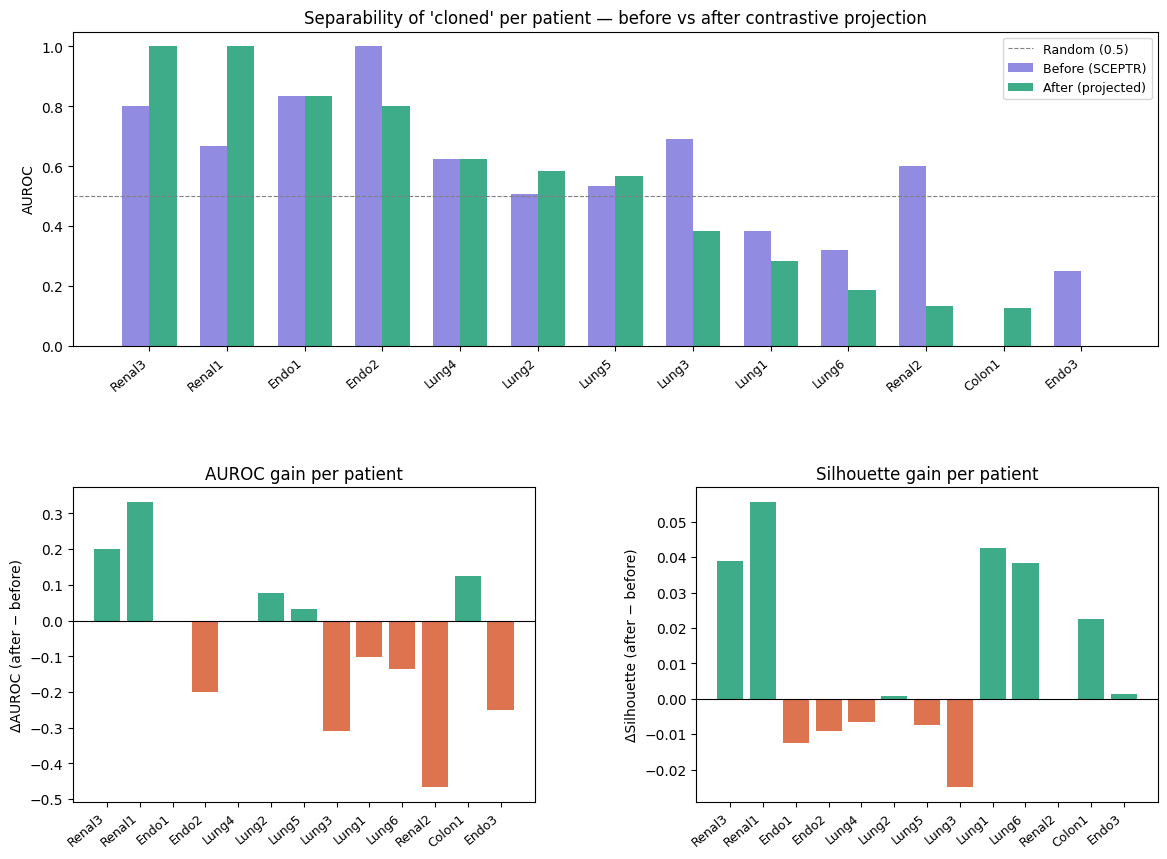

In [46]:
patients = results['patient'].tolist()
x = np.arange(len(patients))
w = 0.35

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── AUROC before vs after ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(x - w/2, results['auroc_before'], w, label='Before (SCEPTR)',      color='#7F77DD', alpha=0.85)
ax1.bar(x + w/2, results['auroc_after'],  w, label='After (projected)',    color='#1D9E75', alpha=0.85)
ax1.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random (0.5)')
ax1.set_xticks(x)
ax1.set_xticklabels(patients, rotation=40, ha='right', fontsize=9)
ax1.set_ylabel('AUROC')
ax1.set_ylim(0, 1.05)
ax1.set_title("Separability of 'cloned' per patient — before vs after contrastive projection")
ax1.legend(fontsize=9)

# ── ΔAUROC ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
colors = ['#1D9E75' if d >= 0 else '#D85A30' for d in results['auroc_delta']]
ax2.bar(x, results['auroc_delta'], color=colors, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(patients, rotation=40, ha='right', fontsize=9)
ax2.set_ylabel('ΔAUROC (after − before)')
ax2.set_title('AUROC gain per patient')

# ── Δsilhouette ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colors_s = ['#1D9E75' if d >= 0 else '#D85A30' for d in results['sil_delta']]
ax3.bar(x, results['sil_delta'], color=colors_s, alpha=0.85)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(patients, rotation=40, ha='right', fontsize=9)
ax3.set_ylabel('ΔSilhouette (after − before)')
ax3.set_title('Silhouette gain per patient')

plt.savefig('separability_results.png', dpi=150, bbox_inches='tight')
plt.show()